In [1]:

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("..")

from src.signals import hat_function
from src.fourier_series import fourier_series_coefficients, fourier_series_reconstruct


## 1. Fourier-Reihe (Reelle Fourier-Reihe)

#### 🔷 Approximation auf $[-\pi, \pi]$:
$$f(t) \approx \frac{a_0}{2} + \sum_{k=1}^N a_k \cos(kt) + b_k \sin(kt)$$

#### 🔷 Allgemeine Formel auf $[-L, L]$ (hier $\text{halbe Periode } L = \pi \implies$ Periode $2L = 2\pi$):
$$f(t) \approx \frac{a_0}{2} + \sum_{k=1}^{N} a_k \cos\left(\frac{k \pi t}{L}\right) + b_k \sin\left(\frac{k \pi t}{L}\right)$$

> „Der Funktionswert $f(t)$ beschreibt das reelle Gesamtamplitude (die momentane Amplitude an diesem Moment t bzw. Winkel x der Fourier-Amplitude). Über die reelle Fourier-Reihe wird diese Amplitude durch orthogonale Projektion auf die reelle Basis $\{\cos(kt), \sin(kt)\}$ in ihre symmetrischen (Kosinus) und antisymmetrischen (Sinus) Frequenzanteile zerlegt.“


#### 🔷 Von der Gesamtamplitude zur orthogonalen Zerlegung (Orthogonale Projektion & Normierung):

> An jeder Stelle $t$ misst $f(t) \in \mathbb{R}$ eine reelle Gesamtamplitude (Signal) (z. B. den Radiusversatz auf dem Kreis).  

>1. **Orthogonale Projektion (Projektionsformel):** 
>
>Die reellen Skalare (Fourier-Koeffizienten) $a_k$ und $b_k$ entstehen durch Skalarprodukte mit den Basisfunktionen:
>>
>> $$a_k = {\color{green}{\frac{1}{\left\|\cos\left(\frac{k \pi t}{L}\right)\right\|^2}}} \left\langle f(t), \; \cos\left(\frac{k \pi t}{L}\right) \right\rangle , \quad b_k = {\color{green}{\frac{1}{\left\|\sin\left(\frac{k \pi t}{L}\right)\right\|^2}}} \left\langle f(t), \; \sin\left(\frac{k \pi t}{L}\right) \right\rangle $$
> >    Sie messen exakt, wie viel von der Schwingung $\cos(kx)$ bzw. $\sin(kx)$ im Signal $f$ vertreten ist.
>> * **Koeffizienten-Integrale:**
>>>  * **Gleichanteil (Mittelwert):**  
>>>    $$a_0 = {{\color{green}\frac{1}{\pi}}} \int_{-\pi}^{\pi} f(t) \cdot 1\, dt$$
>>>    $$\mathbf{\frac{1}{2\pi}} \int_{-\pi}^{\pi} f(t) \, dt = \frac{1}{\mathbf{2}} \cdot \underbrace{\left( {\color{green}{\mathbf{\frac{1}{\pi}}}} \int_{-\pi}^{\pi} f(t) \, dt \right)}_{\text{Das wird als } a_0 \text{ definiert}} = \mathbf{\frac{a_0}{2}}$$
>>>  * **Cosinus-Koeffizienten:**  
>>>    $$a_k = {\color{green}{\frac{1}{\pi}}} \int_{-\pi}^{\pi} f(t) \cos(kt)\, dt$$
>>>  * **Sinus-Koeffizienten:**  
>>>    $$b_k = {\color{green}{\frac{1}{\pi}}} \int_{-\pi}^{\pi} f(t) \sin(kt)\, dt = \mathbf{0} \quad \text{(da $f$ gerade)}$$
>>
>>  - **Normquadrat der Basisfunktion:**
  >>$$\left\|\cos\left(\frac{k \pi t}{L}\right)\right\|^2 = \int_{-L}^{L} \cos^2\left(\frac{k \pi t}{L}\right) dt = L \quad \xrightarrow{L=\pi} \quad \mathbf{\pi} \\\\ \left\|\sin\left(\frac{k \pi t}{L}\right)\right\|^2 = \int_{-L}^{L} \sin^2\left(\frac{k \pi t}{L}\right) dt = L \quad \xrightarrow{L=\pi} \quad \mathbf{\pi}$$
  >>>
  >>> Der Sinus ist nur ein um $90^\circ$ ($\frac{\pi}{2}$) phasenverschobener Kosinus: $\sin(kt) = \cos\left(kt - \frac{\pi}{2}\right)$. Wenn man über eine oder mehrere volle Perioden quadriert und integriert, ist die Fläche unter beiden Kurven **exakt gleich groß**. Das gilt für alle Harmonischen $k = 1, 2, 3, \dots$. Bei $k = 0$ verhalten sich die beiden unterschiedlich:
  >>> * **Für den Kosinus ($k=0$):**  
  $\cos(0 \cdot t) = 1$.  
  >>>Das Normquadrat ist:
  >>>$$\|1\|^2 = \int_{-\pi}^{\pi} 1^2\, dt = \mathbf{2\pi} \quad (\text{also } 2L, \text{ doppelt so groß!})$$
  >>>*(Deshalb steht in der Fourier-Reihe vor dem Gleichanteil das **$\frac{a_0}{2}$**!)*
  >>> * **Für den Sinus ($k=0$):**  
  >>>$\sin(0 \cdot t) \equiv 0$.  
  >>>Die Nullfunktion hat die Norm $0$, weshalb es gar keinen Koeffizienten $b_0$ gibt (die Sinus-Summe startet immer erst bei $k=1$).


> 2. **Synthese:** Die reelle Amplitude $f(t)$ wird als Linearkombination dieser orthogonalen Komponenten rekonstruiert (das bloße Aufsummieren (Überlagern) der mit den Koeffizienten skalierten Basisschwingungen):
>    $$f(t) \approx \underbrace{\frac{a_0}{2}}_{\text{Gleichanteil (Offset)}} + \sum_{k=1}^N \underbrace{a_k \cos(kt)}_{\text{gerade Anteile}} + \sum_{k=1}^N \underbrace{b_k \sin(kt)}_{\text{ungerade Anteile}}$$

> 3. **Spezialfall Hutfunktion:** Da die Hutfunktion achsensymmetrisch ($f(-x) = f(x)$) ist, steht sie orthogonal auf allen Sinus-Wellen ($b_k \equiv 0$). Die gesamte reelle Amplitude wird somit **ausschließlich durch die Kosinus-Basis** modelliert.

## 1.1 Definition des Testsignals (Hutfunktion)

Als Testsignal, sei $f(t)$ eine zentrierte Dreiecksfunktion (Hut) auf dem Intervall $[-\pi, \pi]$ mit einer Halbwertsbreite von $h = \frac{\pi}{2}$:

$$f(t) = \max\left(0, \; 1 - \frac{|t|}{\pi/2}\right) = \begin{cases} 
1 - \frac{2}{\pi}|t| & \text{für } |t| \le \frac{\pi}{2} \quad (Q_2+, Q_3-) \\[6pt] 
0 & \text{für } \frac{\pi}{2} < |t| \le \pi \quad (Q_1, Q_4)
\end{cases}$$

**Die wichtigsten Eigenschaften auf einen Blick:**
- **Spitze bei $t = 0$:** Hier erreicht der Hut genau den Maximalwert $1$.
- **Linearer Abfall:** Zu beiden Seiten fällt die Gerade gleichmäßig ab, bis sie bei $t = \pm \frac{\pi}{2}$ die Nullinie erreicht. Außerhalb bleibt das Signal $0$.
- **Achsensymmetrisch:** $f(-t) = f(t)$, was uns die Sinus-Koeffizienten spart ($b_k = 0$).
- **Knicke:** Die Funktion hat drei scharfe Knickstellen (bei $-\frac{\pi}{2}$, $0$ und $+\frac{\pi}{2}$). Genau an diesen Kanten müssen die glatten Cosinus-Wellen arbeiten, um die Ecken nachzubilden.

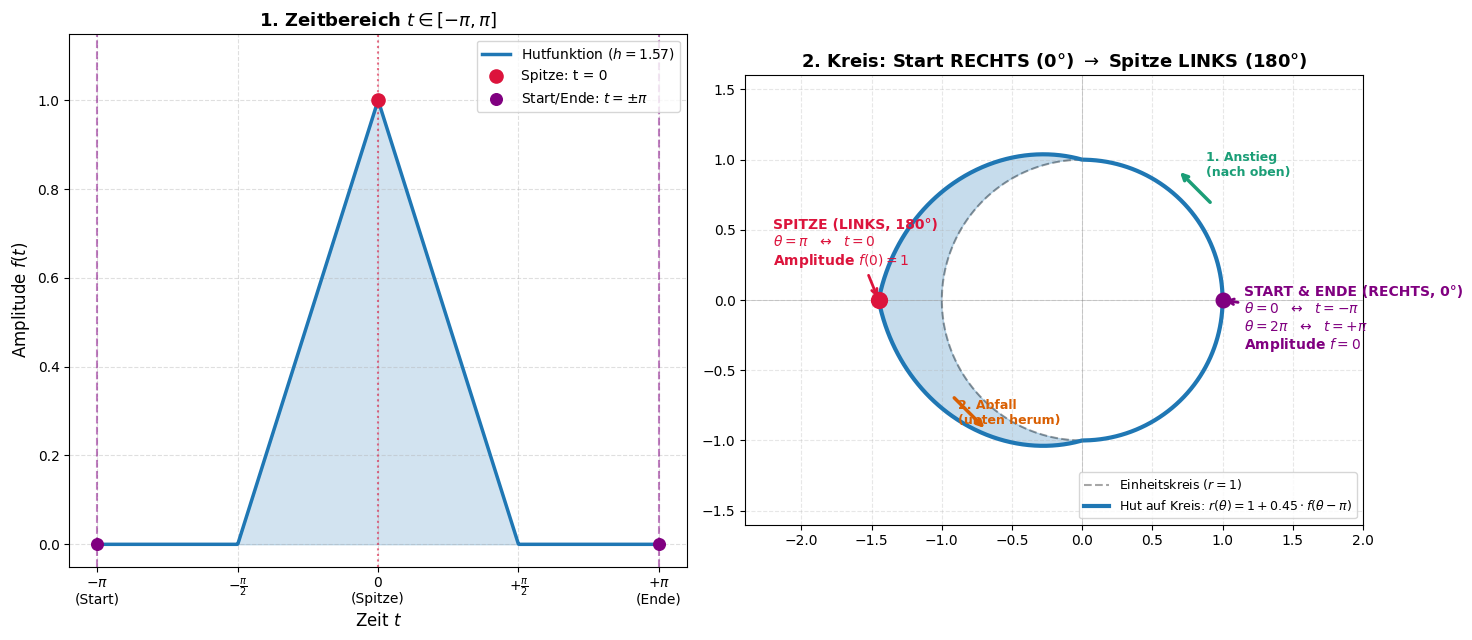

In [2]:
# -------------------------------------------------------------------------
# 1. Parameter & Hutfunktion auf [-pi, pi]
# -------------------------------------------------------------------------
h = (
    np.pi / 2
)  # Halbwertsbreite pi/2 (Hut aktiv zwischen -pi/2 und +pi/2)
# h = np.pi       # Alternativ: Voller Hut über ganz [-pi, pi]


# t läuft von -pi bis +pi
t = np.linspace(-np.pi, np.pi, 1000)
f = hat_function(t, h)

# Drehwinkel: Startet RECHTS bei theta = 0 und läuft gegen den Uhrzeigersinn bis 2*pi
theta = t + np.pi

# -------------------------------------------------------------------------
# 2. Plot erstellen (2 Subplots nebeneinander)
# -------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

# =========================================================================
# LINKER PLOT: 1D Zeitbereich [-pi, pi]
# =========================================================================
ax1.plot(t, f, color="#1f77b4", lw=2.5, label=f"Hutfunktion ($h = {h:.2f}$)")
ax1.fill_between(t, f, color="#1f77b4", alpha=0.2)

# Schlüsselpunkte markieren
ax1.scatter([0], [1], color="crimson", s=90, zorder=5, label="Spitze: t = 0")
ax1.scatter(
    [-np.pi, np.pi],
    [f[0], f[-1]],
    color="purple",
    s=70,
    zorder=5,
    label=r"Start/Ende: $t = \pm\pi$",
)

# Hilfslinien
ax1.axvline(0, color="crimson", linestyle=":", alpha=0.6)
ax1.axvline(-np.pi, color="purple", linestyle="--", alpha=0.5)
ax1.axvline(np.pi, color="purple", linestyle="--", alpha=0.5)

ax1.set_title(
    r"1. Zeitbereich $t \in [-\pi, \pi]$", fontsize=13, fontweight="bold"
)
ax1.set_xlabel(r"Zeit $t$", fontsize=12)
ax1.set_ylabel(r"Amplitude $f(t)$", fontsize=12)

# Ticks und Labels
ticks_x = [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
labels_x = [
    r"$-\pi$" "\n(Start)",
    r"$-\frac{\pi}{2}$",
    r"$0$" "\n(Spitze)",
    r"$+\frac{\pi}{2}$",
    r"$+\pi$" "\n(Ende)",
]
ax1.set_xticks(ticks_x)
ax1.set_xticklabels(labels_x)

ax1.set_ylim([-0.05, 1.15])
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend(loc="upper right")

# =========================================================================
# RECHTER PLOT: Kreis (Start RECHTS, Drehung nach oben, Spitze LINKS)
# =========================================================================
R0 = 1.0  # Radius des Einheitskreises
A = 0.45  # Auslenkung des Hutes
r_signal = R0 + A * f

# 1. Einheitskreis (Ruhelage f = 0)
theta_full = np.linspace(0, 2 * np.pi, 500)
x_circ = R0 * np.cos(theta_full)
y_circ = R0 * np.sin(theta_full)
ax2.plot(x_circ, y_circ, "k--", alpha=0.35, label="Einheitskreis ($r = 1$)")

# 2. Hutfunktion auf dem Kreis
x_sig = r_signal * np.cos(theta)
y_sig = r_signal * np.sin(theta)
ax2.plot(
    x_sig,
    y_sig,
    color="#1f77b4",
    lw=3,
    label=r"Hut auf Kreis: $r(\theta) = 1 + 0.45 \cdot f(\theta - \pi)$",
)

# 3. Fläche sauber füllen (als geschlossenes Polygon)
x_base = R0 * np.cos(theta)
y_base = R0 * np.sin(theta)
x_poly = np.concatenate([x_sig, x_base[::-1]])
y_poly = np.concatenate([y_sig, y_base[::-1]])
ax2.fill(x_poly, y_poly, color="#1f77b4", alpha=0.25)

# 4. SPITZE LINKS (theta = pi, t = 0)  --> OHNE \iff
x_spitze = -(R0 + A)
ax2.scatter([x_spitze], [0], color="crimson", s=130, zorder=6)
ax2.annotate(
    "SPITZE (LINKS, 180°)\n"
    r"$\theta = \pi$  $\leftrightarrow$  $t = 0$"
    "\n"
    r"Amplitude $f(0) = 1$",
    xy=(x_spitze, 0),
    xytext=(x_spitze - 0.75, 0.25),
    arrowprops=dict(arrowstyle="->", color="crimson", lw=2),
    fontweight="bold",
    color="crimson",
    fontsize=10,
)

# 5. START & ENDE RECHTS (theta = 0 bzw. 2*pi, t = -pi bzw. +pi) --> OHNE \iff
ax2.scatter([R0], [0], color="purple", s=110, zorder=6)
ax2.annotate(
    "START & ENDE (RECHTS, 0°)\n"
    r"$\theta = 0$  $\leftrightarrow$  $t = -\pi$"
    "\n"
    r"$\theta = 2\pi$  $\leftrightarrow$  $t = +\pi$"
    "\n"
    r"Amplitude $f = 0$",
    xy=(R0, 0),
    xytext=(R0 + 0.15, -0.35),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2),
    fontweight="bold",
    color="purple",
    fontsize=10,
)

# 6. Drehrichtungspfeile (nach OBEN gegen den Uhrzeigersinn)
th_arr1 = np.pi / 4
ax2.annotate(
    "",
    xy=(1.15 * np.cos(th_arr1 + 0.15), 1.15 * np.sin(th_arr1 + 0.15)),
    xytext=(1.15 * np.cos(th_arr1 - 0.15), 1.15 * np.sin(th_arr1 - 0.15)),
    arrowprops=dict(arrowstyle="->", color="#1b9e77", lw=2.5),
)
ax2.text(
    1.25 * np.cos(th_arr1),
    1.25 * np.sin(th_arr1),
    "1. Anstieg\n(nach oben)",
    color="#1b9e77",
    fontweight="bold",
    fontsize=9,
)

th_arr2 = 5 * np.pi / 4
ax2.annotate(
    "",
    xy=(1.15 * np.cos(th_arr2 + 0.15), 1.15 * np.sin(th_arr2 + 0.15)),
    xytext=(1.15 * np.cos(th_arr2 - 0.15), 1.15 * np.sin(th_arr2 - 0.15)),
    arrowprops=dict(arrowstyle="->", color="#d95f02", lw=2.5),
)
ax2.text(
    1.25 * np.cos(th_arr2),
    1.25 * np.sin(th_arr2),
    "2. Abfall\n(unten herum)",
    color="#d95f02",
    fontweight="bold",
    fontsize=9,
)

# Achsenkreuz
ax2.axhline(0, color="gray", lw=0.6, alpha=0.4)
ax2.axvline(0, color="gray", lw=0.6, alpha=0.4)

ax2.set_title(
    "2. Kreis: Start RECHTS (0°) $\\rightarrow$ Spitze LINKS (180°)",
    fontsize=13,
    fontweight="bold",
)
ax2.set_aspect("equal")
ax2.set_xlim([-2.4, 2.0])
ax2.set_ylim([-1.6, 1.6])
ax2.grid(True, linestyle="--", alpha=0.3)
ax2.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


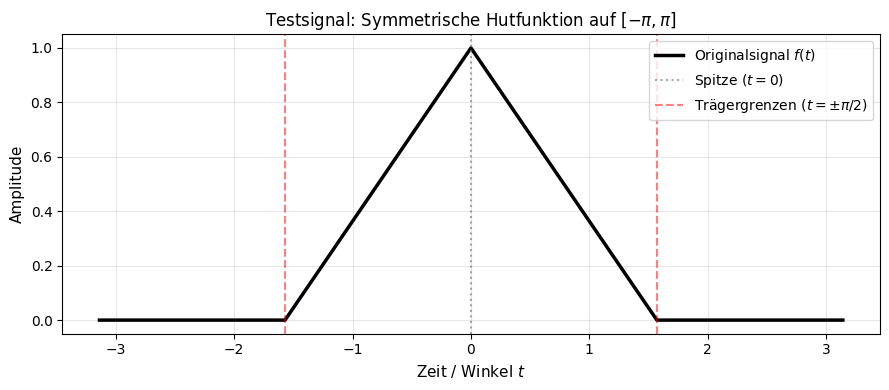

In [3]:
# -------------------------------------------------------------------------
# 1. Definitionsbereich und Testsignal

dt = 0.001
L = np.pi 
t = L * np.arange(-1 + dt, 1 + dt, dt) # 2000 Stützstellen
f = hat_function(t)                    # Testsignal aus signals.py

# Signal visualisieren
plt.figure(figsize=(9, 4))
plt.plot(t, f, 'k-', lw=2.5, label=r'Originalsignal $f(t)$')
plt.axvline(0, color='gray', linestyle=':', alpha=0.7, label=r'Spitze ($t=0$)')
plt.axvline(-np.pi/2, color='r', linestyle='--', alpha=0.5, label=r'Trägergrenzen ($t=\pm \pi/2$)')
plt.axvline(np.pi/2, color='r', linestyle='--', alpha=0.5)
plt.title(r'Testsignal: Symmetrische Hutfunktion auf $[-\pi, \pi]$', fontsize=12)
plt.xlabel(r'Zeit / Winkel $t$', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


0.0031415926535897933
Gleichanteil a_0 = 0.500000 (analytisch: 0.500000)
Cosinus-Koeffizienten a_1 bis a_5: [ 0.202643  0.045032 -0.        0.016212  0.022516]
Maximaler Sinus-Koeffizient max(|B_k|): 2.84e-17 (Maschinengenauigkeit-exakt 0)


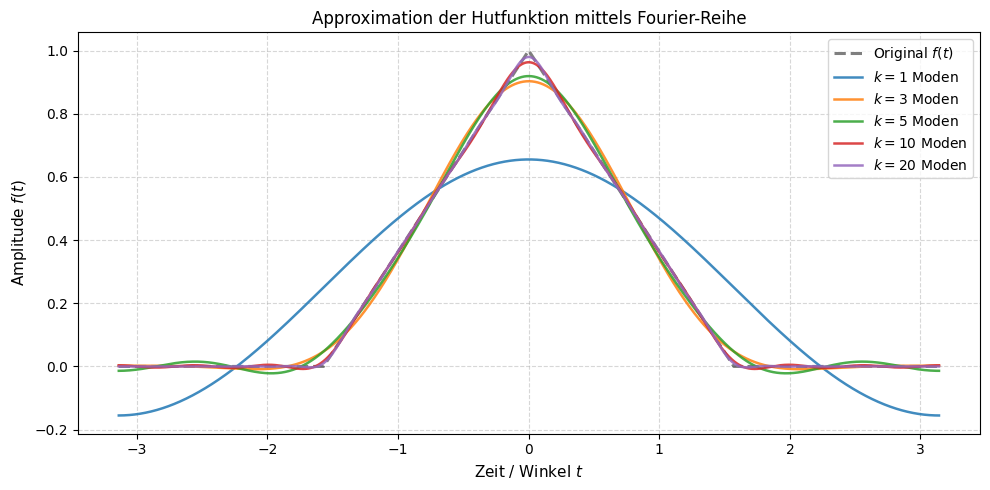

In [4]:
# -------------------------------------------------------------------------
# 2. Fourier-Reihe berechnen und statischer Vergleich


# 1. Fourier-Koeffizienten berechnen (Analyse)
R = 20
a0, A_k, B_k = fourier_series_coefficients(t, dt * np.pi, f, R=R) # Schritte hier sind in Rad

print(f"Gleichanteil a_0 = {a0:.6f} (analytisch: 0.500000)")
print(f"Cosinus-Koeffizienten a_1 bis a_5: {np.round(A_k[1:6], 6)}")
print(f"Maximaler Sinus-Koeffizient max(|B_k|): {np.max(np.abs(B_k)):.2e} (Maschinengenauigkeit-exakt 0)")

# 2. Rekonstruktion für verschiedene Moden k plotten
plt.figure(figsize=(10, 5))
plt.plot(t, f, 'k--', lw=2.2, alpha=0.5, label=r'Original $f(t)$')

# Für ausgewählte Modenanzahlen k das Signal rekonstruieren
for k in [1, 3, 5, 10, 20]:
    fFS = fourier_series_reconstruct(t, a0, A_k, B_k, R=k)
    plt.plot(t, fFS, label=f'$k = {k}$ Moden', alpha=0.85, lw=1.8)

plt.title('Approximation der Hutfunktion mittels Fourier-Reihe', fontsize=12)
plt.xlabel(r'Zeit / Winkel $t$', fontsize=11)
plt.ylabel(r'Amplitude $f(t)$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [5]:
# -------------------------------------------------------------------------
# 3. Interaktive Erkundung mit Schieberegler
from src.visualization import plot_fourier_interactive

# rechnet vorab 40-Auflösungen und wird per Slider gesteuert angezeigt
plot_fourier_interactive(t, dt * np.pi, f, R_max=40) 

0.0031415926535897933


## 1.2 Wie schnell nähert sich die Reihe an? (Konvergenz)

> Die Natur des Signals bestimmt die Glattheit ($C^0$) $\implies$ die Glattheit bestimmt den quadratischen Koeffizienten-Decay ($\mathcal{O}(1/k^2)$) $\implies$ der Decay bestimmt das Konvergenztempo gegen das Originalsignal.

- **Glattheit bestimmt das Tempo (Koeffizienten-Decay-Abfall):**  
  In der Fourier-Analysis gilt die Faustregel: Je glatter eine Funktion, desto schneller fallen ihre Koeffizienten ab. Da unsere Hutfunktion (linearer-Spline) stetig ist, aber harte Knicke hat (die Ableitung springt(vor 0 +, nach 0 -)), fallen die Koeffizienten langsamer mit $f \in C^{p-1}$ und $f^{(p)}$ stückweise stetig $\implies a_k = \mathcal{O}(k^{-(p+1)})$, hier: $p=1$ ($f \in C^0$, Knickstellen an der Spitze und den Rändern):
  $$a_k = \mathcal{O}\left(\frac{1}{k^2}\right)$$
  Höhere Frequenzen werden also quadratisch kleiner und tragen immer feinere Details bei.

- **Zusammenspiel an der Spitze ($t = 0$):**  
  Für $t = 0$ ist $\cos(k \cdot 0) = 1$ für jedes beliebige $k \in [1,N]$. Das bedeutet: Alle Harmonischen haben hier ihr Maximum und ziehen am selben Strang:
  $$f(0) \approx \frac{a_0}{2} + \sum_{k=1}^N a_k = 1$$
  Die negative Krümmung der Cosinus-Wellen ($-k^2$) sorgt dafür, dass sich die scharfe Spitze immer spitzer ausbildet.

#### Die Natur des Signals (Glattheitsklasse im Zeit-/Ortsraum)
* **Geometrische Eigenschaft:** Unsere Hutfunktion ist stetig, besitzt aber drei harte Knickstellen (bei $t = -\frac{\pi}{2}, 0, \frac{\pi}{2}$). 
* **Mathematische Einordnung:** $f \in C^0$, aber $f \notin C^1$ (die erste Ableitung springt an den Kanten).
* **Auswirkung:** Da die Basisfunktionen ($\cos, \sin$) von Natur aus rund und weich sind, können sie Knicke nicht sofort abbilden. Sie benötigen zwingend viele kurzwellige Obertöne hoher Frequenz.



#### Die Decay-Rate der Koeffizienten (Frequenzbereich)
* **Abfallgesetz:** Ist die $p$-te Ableitung stückweise stetig, fallen die Fourier-Koeffizienten mit $a_k = \mathcal{O}\left(k^{-(p+1)}\right)$ ab.
* **Für die Hutfunktion ($p=1$):**
  $$a_k = \mathcal{O}\left(\frac{1}{k^2}\right)$$
* **Bedeutung für die Annäherung:** 
  * Höhere Frequenzen $k$ werden quadratisch schwächer ($\frac{1}{1}, \frac{1}{4}, \frac{1}{9}, \frac{1}{16}, \dots$).
  * Sie tragen nur noch für die mikroskopische Schärfung der Spitze bei.
  * Der Approximationsfehler sinkt stetig mit jedem Summanden gegen $0$.

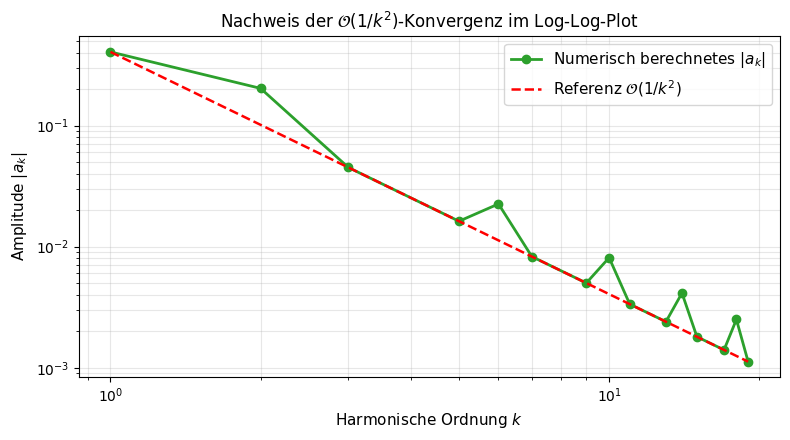

In [6]:
# 1. Indizes k = 1 bis R (Länge R)
k_indices = np.arange(1, R + 1)

# 2. Beträge aller Amplituden a_k (einschl. a0) 
# -> Der reine absolute Betrag (die Stärke / Lautstärke der Schwingung, egal in welche Richtung)
a_magnitudes = np.abs(A_k)

# 3. Maske für Koeffizienten > Maschinengenauigkeit (Auslöschung von geraden Moden/Nullen abfangen)
mask = a_magnitudes > 1e-12
k_valid = k_indices[mask]
a_valid = a_magnitudes[mask]
#print(mask)

# 4. Log-Log-Plot zur Konvergenzüberprüfung
plt.figure(figsize=(8, 4.5))
plt.loglog(k_valid, a_valid, 'o-', color='tab:green', lw=2, ms=6, label=r'Numerisch berechnetes $|a_k|$')
plt.loglog(k_valid, a_valid[0] * (k_valid[0] / k_valid)**2, 'r--', lw=1.8, label=r'Referenz $\mathcal{O}(1/k^2)$')

plt.title(r'Nachweis der $\mathcal{O}(1/k^2)$-Konvergenz im Log-Log-Plot', fontsize=12)
plt.xlabel('Harmonische Ordnung $k$', fontsize=11)
plt.ylabel(r'Amplitude $|a_k|$', fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 1.3 Numerische Stabilität: Rundungsfehler & Konditionierung

- **Keine Auslöschung:**  
  Gefährliche Auslöschung (Catastrophic Cancellation) passiert in Gleitkommazahlen nur, wenn zwei fast gleich große Zahlen voneinander subtrahiert werden. An der Spitze summieren wir aber lauter positive Werte ($a_k \ge 0$) auf. Auslöschung ist also ausgeschlossen.

- **Gutartige Konditionierung:**  
  Eine einfache Summe besitzt die absolute Konditionszahl $\kappa_{\text{abs}} = 1$. Eingabefehler werden also nicht künstlich verstärkt.

- **Rundungsfehler in float64:**  
  Bei doppelter Genauigkeit (ca. 16 Dezimalstellen) liegt der akkumulierte Rundungsfehler selbst bei $N = 1000$ Summanden in der Größenordnung von $\approx 10^{-13}$. Der Rechenfehler am Rechner ist also praktisch vernachlässigbar.